# ECHR Court Decision Analysis
## Violation Prediction & Article Classification using Legal-BERT

**Authors:** Pelin Kımız & Anıl Yazıcı  
**Model:** `nlpaueb/legal-bert-base-uncased`  
**Dataset:** [glnmario/ECHR](https://huggingface.co/datasets/glnmario/ECHR) — 11,478 English ECHR judgments (1960–2018)  

---

### Research Questions
1. **Task 1 — Binary Classification:** Can Legal-BERT predict whether an ECHR judgment results in a violation?
2. **Task 2 — Multi-class Classification:** Can Legal-BERT identify which Convention article was violated?

### Results Summary
| Task | Test Macro F1 | Accuracy |
|------|:------------:|:--------:|
| Task 1: Violation vs No Violation | **0.84** | **0.87** |
| Task 2: Article Classification (7 classes) | **0.62** | **0.70** |

### Dataset
| Split | Task 1 | Task 2 |
|-------|-------:|-------:|
| Train | 7,100 | 3,293 |
| Val | 1,380 | 650 |
| Test | 2,998 | 1,822 |

### Articles Covered (Task 2)
| Article | Topic | Train cases |
|---------|-------|------------:|
| Art. 6 | Right to a fair trial | 1,749 |
| Art. 3 | Prohibition of torture | 435 |
| Art. 5 | Right to liberty and security | 413 |
| Art. 8 | Right to respect for private life | 272 |
| Art. 2 | Right to life | 198 |
| Art. 10 | Freedom of expression | 172 |
| Art. 1 | Protection of property (P1) | 54 |

## Setup & Dependencies

In [ ]:
# Install dependencies
!pip install transformers datasets torch -q

import torch, re, numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME   = 'nlpaueb/legal-bert-base-uncased'
MAX_LEN      = 512
BATCH_SIZE   = 16
EPOCHS_T1    = 3
EPOCHS_T2    = 4
LR           = 2e-5
TOP_ARTICLES = ['6', '3', '5', '8', '2', '10', '1']

print(f'Device: {DEVICE}')

## 1. Data Preparation

In [ ]:
dataset  = load_dataset('glnmario/ECHR')
train_df = pd.DataFrame(dataset['train'])
print(f'Dataset loaded: {train_df.shape}')
print(train_df.columns.tolist())

def extract_articles(conclusion):
    if pd.isna(conclusion): return []
    articles  = re.findall(r'Violations?\s+of Art\.\s*([\d\w][\d\w-]*)', str(conclusion))
    articles += re.findall(r'Violations?\s+of Article\s+(\d+)', str(conclusion))
    for art, prot in re.findall(r'Article\s+(\d+)\s+of Protocol No\.\s*(\d+)', str(conclusion)):
        articles.append(f'P{prot}-{art}')
    seen, unique = set(), []
    for a in articles:
        if a not in seen: seen.add(a); unique.append(a)
    return unique

def get_primary_article(arts):
    if not arts: return None
    a = arts[0]
    if a.startswith('6'): return '6'
    if a.startswith('5'): return '5'
    return a

train_df['violated_articles'] = train_df['conclusion'].apply(extract_articles)
train_df['primary_article']   = train_df['violated_articles'].apply(get_primary_article)
train_df['text_length']       = train_df['text'].apply(lambda x: len(x.split()))
article_to_id = {art: idx for idx, art in enumerate(TOP_ARTICLES)}

# Task 1 splits
task1_df = train_df[['itemid','text','binary_judgement','respondent','date','partition']].copy()
task1_df = task1_df.rename(columns={'binary_judgement': 'label'})
task1_train = task1_df[task1_df['partition']=='train'].reset_index(drop=True)
task1_val   = task1_df[task1_df['partition']=='dev'].reset_index(drop=True)
task1_test  = task1_df[task1_df['partition']=='test'].reset_index(drop=True)

# Task 2 splits
task2_df = train_df[
    (train_df['binary_judgement']==1) &
    (train_df['primary_article'].isin(TOP_ARTICLES))
].copy()
task2_df['label'] = task2_df['primary_article'].map(article_to_id)
task2_df = task2_df[['itemid','text','label','primary_article','respondent','date','partition']].copy()
task2_train = task2_df[task2_df['partition']=='train'].reset_index(drop=True)
task2_val   = task2_df[task2_df['partition']=='dev'].reset_index(drop=True)
task2_test  = task2_df[task2_df['partition']=='test'].reset_index(drop=True)

print(f'Task1 — Train: {len(task1_train)} | Val: {len(task1_val)} | Test: {len(task1_test)}')
print(f'Task2 — Train: {len(task2_train)} | Val: {len(task2_val)} | Test: {len(task2_test)}')

## 2. Exploratory Data Analysis

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ECHR Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Violation distribution
axes[0,0].bar(['No Violation (0)', 'Violation (1)'],
               train_df['binary_judgement'].value_counts().sort_index(),
               color=['#2196F3', '#F44336'], edgecolor='white')
axes[0,0].set_title('Violation vs No Violation')
axes[0,0].set_ylabel('Number of Cases')
for i, v in enumerate(train_df['binary_judgement'].value_counts().sort_index()):
    axes[0,0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Top 15 countries
top_countries = train_df['respondent'].value_counts().head(15)
axes[0,1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#4CAF50')
axes[0,1].set_title('Top 15 Respondent Countries')
axes[0,1].set_xlabel('Number of Cases')

# Cases over time
cases_by_year = train_df['date'].value_counts().sort_index()
axes[1,0].plot(cases_by_year.index, cases_by_year.values, color='#9C27B0', linewidth=2)
axes[1,0].fill_between(cases_by_year.index, cases_by_year.values, alpha=0.3, color='#9C27B0')
axes[1,0].set_title('Number of Cases Over Time')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Number of Cases')

# Text length
axes[1,1].hist(train_df['text_length'].clip(upper=10000), bins=50, color='#FF9800', edgecolor='white')
axes[1,1].set_title('Text Length Distribution (words, clipped at 10k)')
axes[1,1].set_xlabel('Number of Words'); axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(train_df['text_length'].median(), color='red', linestyle='--',
                  label=f"Median: {int(train_df['text_length'].median())}")
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 3. Model Utilities

In [ ]:
class ECHRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            max_length=self.max_len, padding='max_length', return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

def build_loaders(train_df, val_df, test_df, tokenizer, max_len, batch_size):
    return (
        DataLoader(ECHRDataset(train_df['text'].tolist(), train_df['label'].tolist(), tokenizer, max_len), batch_size=batch_size, shuffle=True),
        DataLoader(ECHRDataset(val_df['text'].tolist(),   val_df['label'].tolist(),   tokenizer, max_len), batch_size=batch_size, shuffle=False),
        DataLoader(ECHRDataset(test_df['text'].tolist(),  test_df['label'].tolist(),  tokenizer, max_len), batch_size=batch_size, shuffle=False),
    )

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for i, batch in enumerate(loader):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, labels=labs)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
        all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
        if (i+1) % 50 == 0:
            print(f'  Step {i+1}/{len(loader)} | Loss: {out.loss.item():.4f}')
    return total_loss/len(loader), f1_score(all_labels, all_preds, average='macro')

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=labs)
            total_loss += out.loss.item()
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
    return total_loss/len(loader), f1_score(all_labels, all_preds, average='macro'), all_preds, all_labels

def run_training(model, train_loader, val_loader, optimizer, scheduler, epochs, save_path):
    best_val_f1, history = 0, []
    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}\n' + '-'*40)
        tr_loss, tr_f1         = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_loss, val_f1, _, _ = eval_epoch(model, val_loader, DEVICE)
        history.append({'epoch': epoch+1, 'train_loss': tr_loss, 'train_f1': tr_f1,
                        'val_loss': val_loss, 'val_f1': val_f1})
        print(f'Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f}')
        print(f'Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ Best model saved (Val F1: {val_f1:.4f})')
    return history, best_val_f1

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')

## 4. Task 1 — Binary Violation Classification

In [ ]:
train_loader_t1, val_loader_t1, test_loader_t1 = build_loaders(
    task1_train, task1_val, task1_test, tokenizer, MAX_LEN, BATCH_SIZE
)

model_t1     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
optimizer_t1 = AdamW(model_t1.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader_t1) * EPOCHS_T1
scheduler_t1 = get_linear_schedule_with_warmup(
    optimizer_t1, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps
)

history_t1, _ = run_training(
    model_t1, train_loader_t1, val_loader_t1,
    optimizer_t1, scheduler_t1, EPOCHS_T1, 'best_task1_model.pt'
)

model_t1.load_state_dict(torch.load('best_task1_model.pt', map_location=DEVICE))
t1_loss, t1_f1, t1_preds, t1_labels = eval_epoch(model_t1, test_loader_t1, DEVICE)
print(f'\nTest Loss: {t1_loss:.4f} | Test Macro F1: {t1_f1:.4f}\n')
print(classification_report(t1_labels, t1_preds, target_names=['No Violation', 'Violation']))

### Task 1 Results

**Test Macro F1: 0.84 | Accuracy: 0.87**

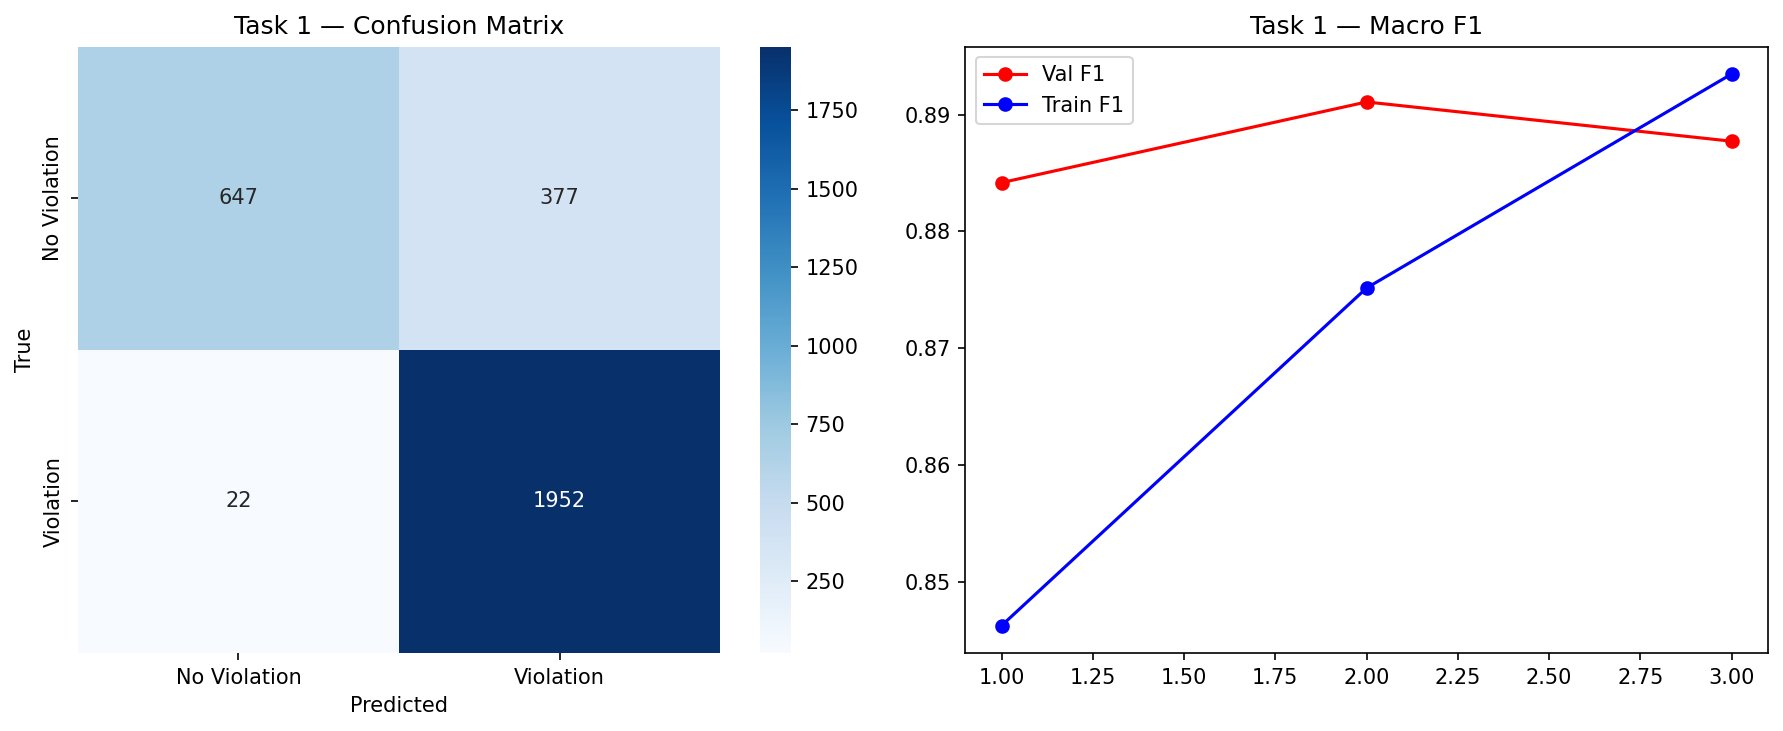

**Key observations:**
- Violation recall: **0.99** — the model captures almost all actual violations
- No Violation recall: **0.63** — harder to classify, reflecting the heterogeneous nature of inadmissible and mixed cases
- Val F1 peaks at Epoch 2 (0.89), slight overfitting in Epoch 3

## 5. Task 2 — Article Classification (7 classes)

In [ ]:
train_loader_t2, val_loader_t2, test_loader_t2 = build_loaders(
    task2_train, task2_val, task2_test, tokenizer, MAX_LEN, BATCH_SIZE
)

model_t2     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=7).to(DEVICE)
optimizer_t2 = AdamW(model_t2.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader_t2) * EPOCHS_T2
scheduler_t2 = get_linear_schedule_with_warmup(
    optimizer_t2, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps
)

history_t2, _ = run_training(
    model_t2, train_loader_t2, val_loader_t2,
    optimizer_t2, scheduler_t2, EPOCHS_T2, 'best_task2_model.pt'
)

model_t2.load_state_dict(torch.load('best_task2_model.pt', map_location=DEVICE))
t2_loss, t2_f1, t2_preds, t2_labels = eval_epoch(model_t2, test_loader_t2, DEVICE)
article_names = [f'Art. {a}' for a in TOP_ARTICLES]
print(f'\nTest Loss: {t2_loss:.4f} | Test Macro F1: {t2_f1:.4f}\n')
print(classification_report(t2_labels, t2_preds, target_names=article_names))

### Task 2 Results

**Test Macro F1: 0.62 | Accuracy: 0.70**

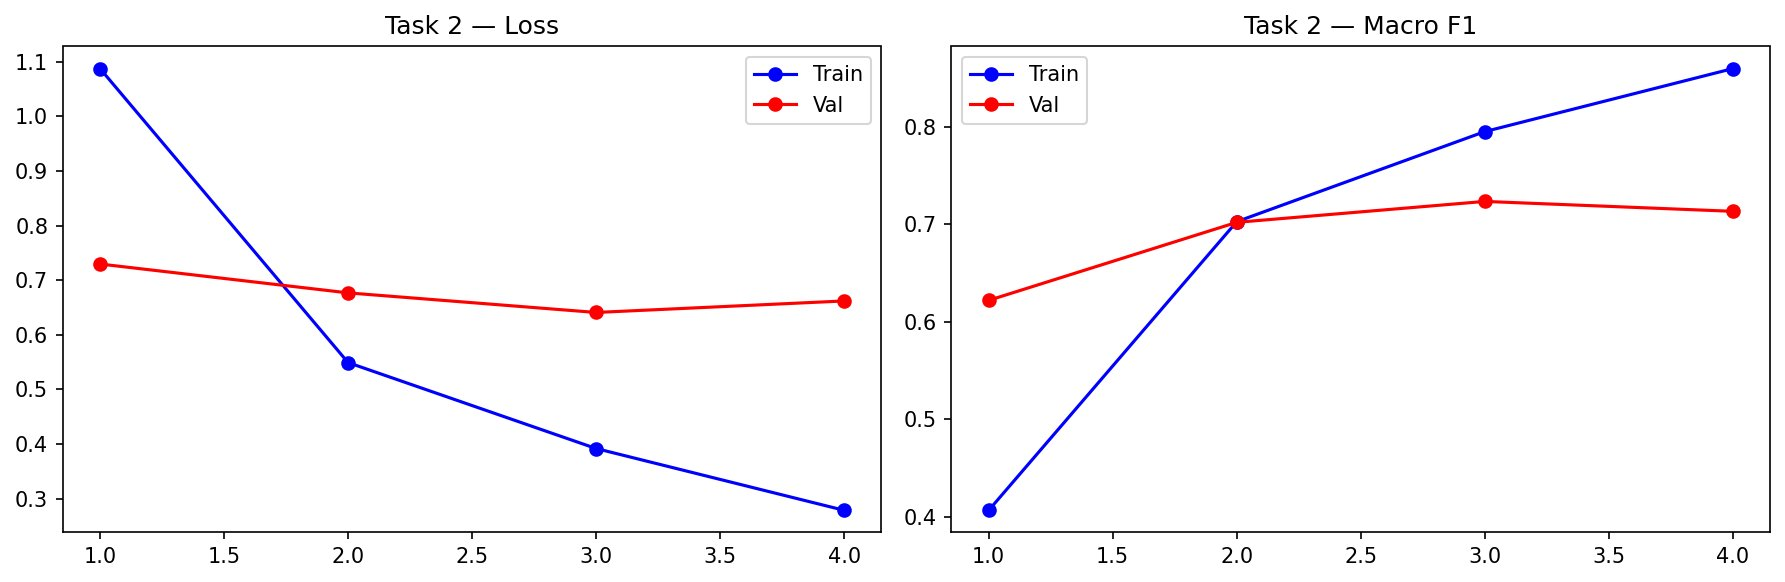

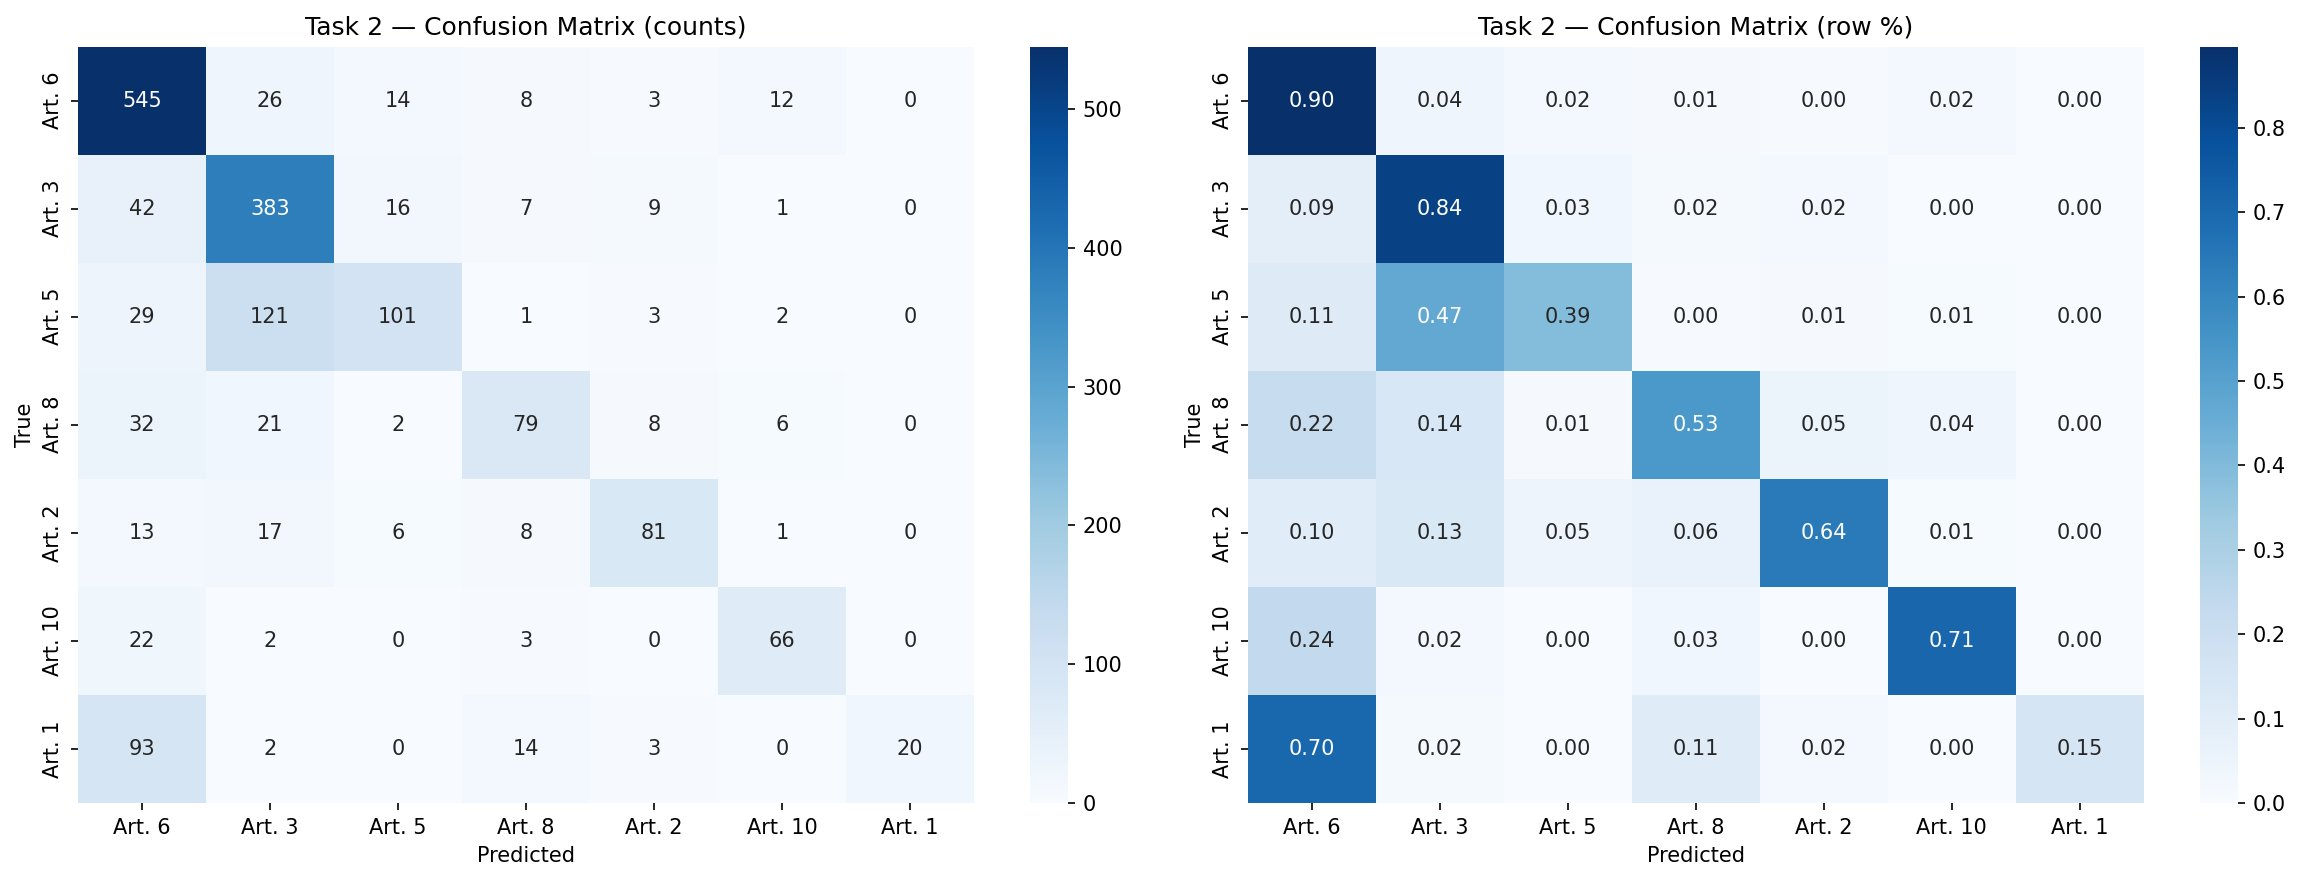

**Key observations:**
- **Art. 6 (0.79)** and **Art. 3 (0.74)** achieve the highest F1, benefiting from larger training sets
- **Art. 1 (0.26)** performs poorly — only 54 training examples and frequent confusion with Art. 6
- **Art. 5 (0.51)** is commonly misclassified as Art. 3 — both involve detention and ill-treatment language
- Val F1 peaks at Epoch 3 (0.72), model saved at best checkpoint

## 6. Country-Level Error Analysis

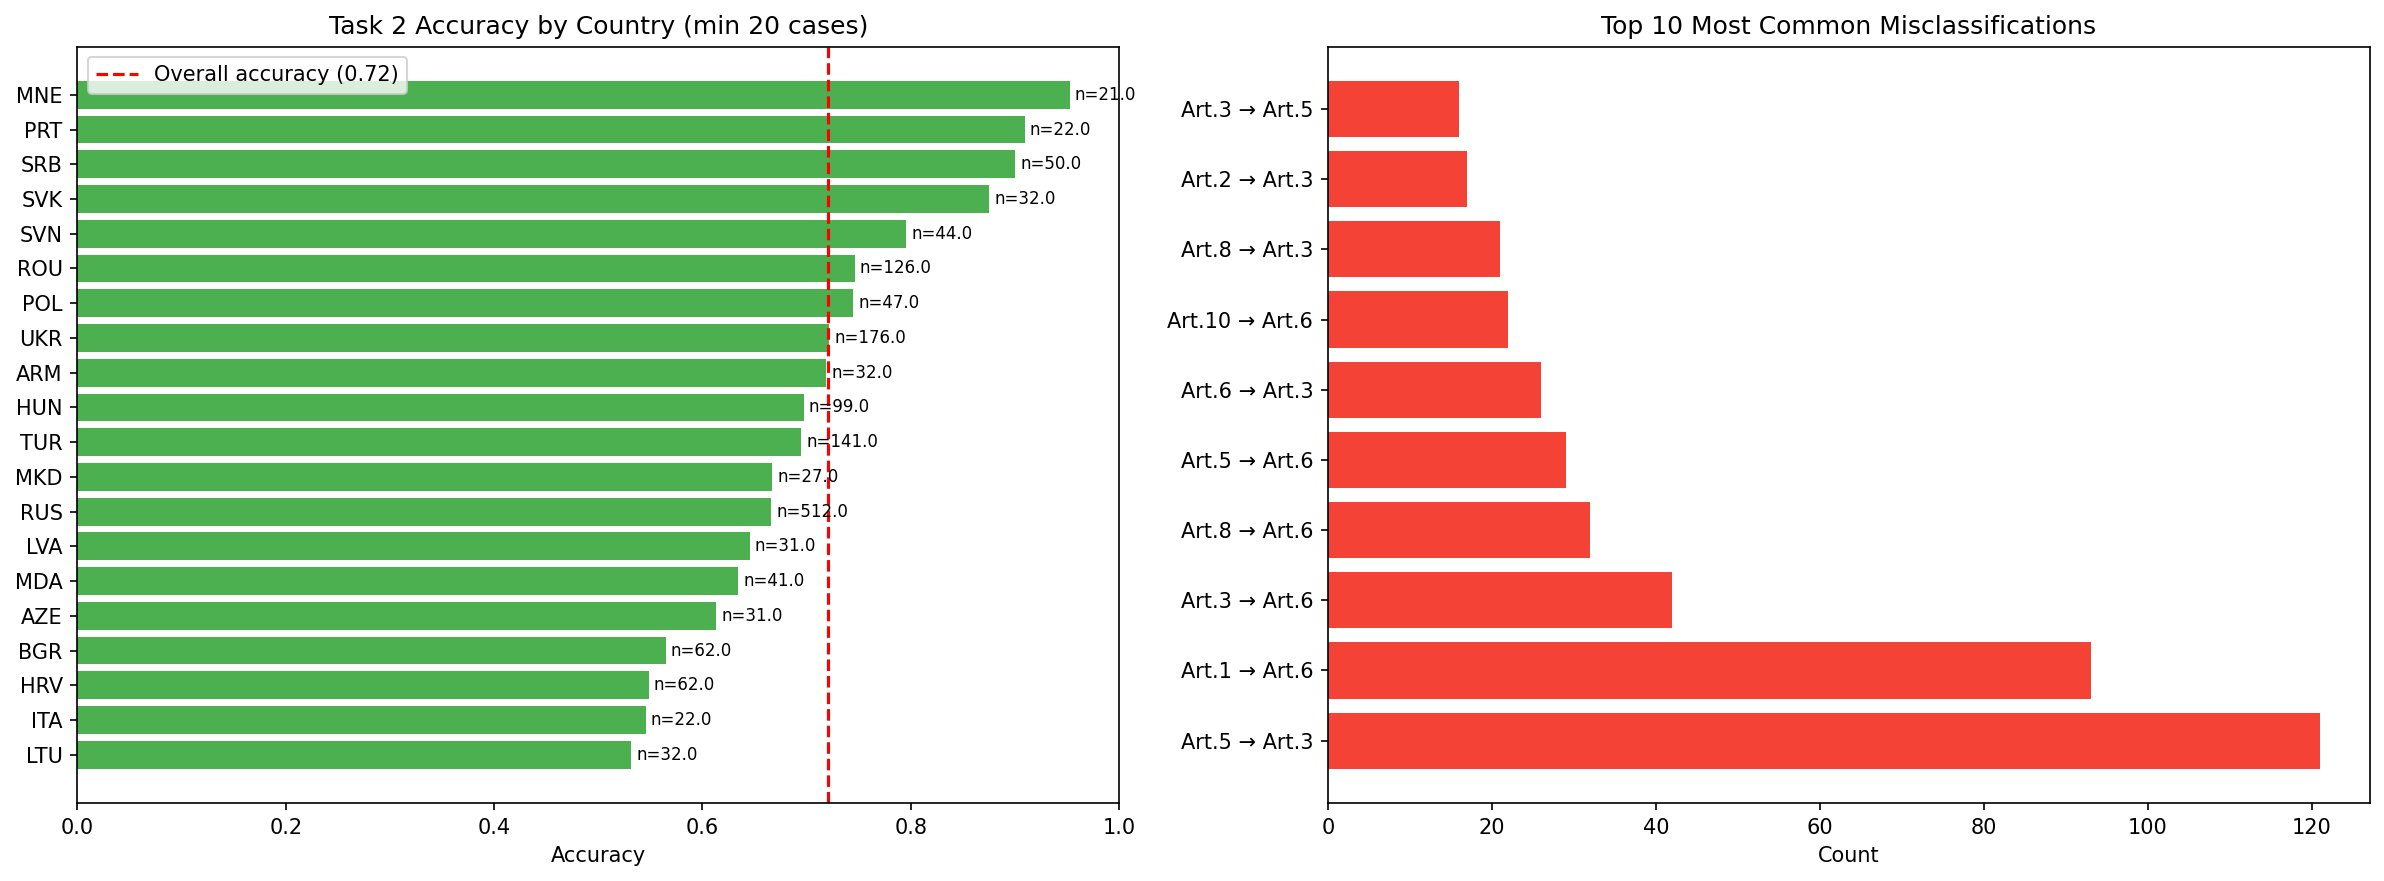

**Key observations:**
- **Montenegro, Portugal, Serbia** achieve the highest accuracy (>0.90)
- **Lithuania, Italy, Croatia** perform below average, likely due to case composition
- **Russia** is the largest test group (n=512) with accuracy close to the overall average
- **Art. 5 → Art. 3** is the most common misclassification (121 cases) — detention and torture cases share overlapping legal language
- **Art. 1 → Art. 6** (93 cases) — property rights cases often co-occur with fair trial violations

## 7. Conclusions

### Task 1 — Violation Prediction
Legal-BERT achieves strong performance (Macro F1: **0.84**, Accuracy: **0.87**) in predicting whether a judgment results in a violation. The model is particularly effective at identifying actual violations (recall: 0.99), making it useful as a screening tool.

### Task 2 — Article Classification
Article classification is significantly harder (Macro F1: **0.62**, Accuracy: **0.70**), reflecting the overlapping legal language across Convention articles. Performance varies substantially across articles, correlating with training set size:
- High-resource articles (Art. 6, Art. 3) perform well
- Low-resource articles (Art. 1) suffer from data imbalance

### Legal Interpretation
The confusion patterns are legally meaningful:
- Art. 5 ↔ Art. 3: Both involve detention conditions and ill-treatment
- Art. 1 → Art. 6: Property disputes frequently entail procedural violations
- Country-level differences may reflect legal traditions and case type distributions

### Future Work
- Class balancing (oversampling Art. 1, weighted loss)
- Longer context window or hierarchical models for long judgments
- Attention visualization to identify predictive legal phrases